# DAC temperature sensitivity to thermal confinement

In a two-volume laser-heated diamond-anvil-cell analysis, the measured cold and
hot volumes do not by themselves determine the hot pressure. Peritheos offers
an explicit empirical boundary condition

$$
P_{hot}-P_{ambient}=f_{DAC}\,P_{thermal}(V_{hot},T),
$$

with $0\le f_{DAC}<1$. This notebook shows how the inferred temperature and its
volume-error sensitivity change across plausible $f_{DAC}$ assumptions. The
numbers are synthetic and illustrate the method; they are not an experimental
calibration.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from peritheos import EOSUncertainty
from peritheos.eos.rt import BM3
from peritheos.eos.thermal import MieGruneisenDebye

plt.style.use("seaborn-v0_8-whitegrid")

reference = BM3(V0=1.0, K0=160.0, K0_prime=4.0)
eos = MieGruneisenDebye(
    rt_eos=reference,
    Tr=300.0,
    theta0=800.0,
    gamma0=1.5,
    q=1.0,
    n=2,
)

ambient_volume = 0.800
heated_volume = 0.805
ambient_pressure = reference.pressure(ambient_volume)

print(f"Cold volume: {ambient_volume:.6f} J bar^-1 mol^-1")
print(f"Hot volume:  {heated_volume:.6f} J bar^-1 mol^-1")
print(f"Cold pressure from the reference isotherm: {ambient_pressure:.3f} GPa")

Cold volume: 0.800000 J bar^-1 mol^-1
Hot volume:  0.805000 J bar^-1 mol^-1
Cold pressure from the reference isotherm: 55.837 GPa


## Infer temperature for several boundary assumptions

The inferred temperature rises with $f_{DAC}$ because a larger confinement
fraction requires more thermal pressure to reconcile the same two measured
volumes.

In [2]:
fractions = np.array([0.0, 0.25, 0.50, 0.75, 0.90])
temperatures = np.array(
    [
        eos.temperature_from_volumes(
            ambient_volume,
            heated_volume,
            f_dac=fraction,
        )
        for fraction in fractions
    ]
)

print(" f_DAC   inferred T (K)")
for fraction, temperature in zip(fractions, temperatures):
    print(f" {fraction:5.2f} {temperature:16.2f}")

 f_DAC   inferred T (K)
  0.00           684.84
  0.25           795.16
  0.50          1008.72
  0.75          1626.86
  0.90          3436.52


## Verify the pressure boundary condition

For each inferred temperature, the ordinary hot EOS pressure must equal the
cold pressure plus the assumed fraction of thermal pressure.

In [3]:
print(" f_DAC   EOS hot P   boundary hot P   difference (GPa)")
for fraction, temperature in zip(fractions, temperatures):
    thermal_pressure = eos.thermal_pressure(heated_volume, temperature)
    eos_hot_pressure = eos.pressure(heated_volume, temperature)
    boundary_hot_pressure = ambient_pressure + fraction * thermal_pressure
    difference = eos_hot_pressure - boundary_hot_pressure
    print(
        f" {fraction:5.2f} {eos_hot_pressure:11.5f} "
        f"{boundary_hot_pressure:16.5f} {difference:18.2e}"
    )

 f_DAC   EOS hot P   boundary hot P   difference (GPa)
  0.00    55.83734         55.83734           0.00e+00
  0.25    56.58200         56.58200           0.00e+00
  0.50    58.07131         58.07131           7.11e-15
  0.75    62.53924         62.53924          -6.82e-13
  0.90    75.94303         75.94303           0.00e+00


## Sweep the confinement fraction

The reduced equation contains $1/(1-f_{DAC})$, so sensitivity increases
rapidly as the fraction approaches one. A value close to one should never be
reported without a defensible experimental basis and a sensitivity analysis.

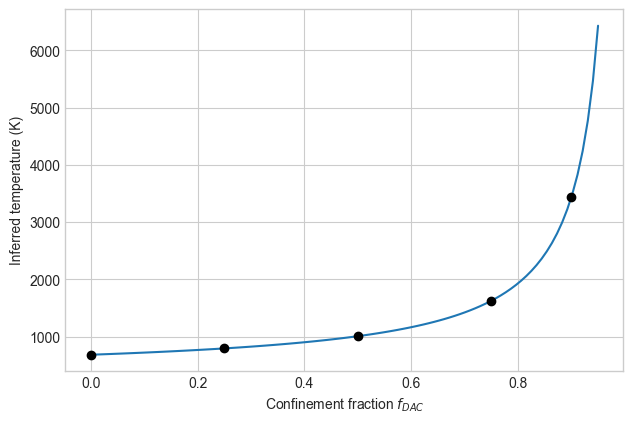

In [4]:
fraction_grid = np.linspace(0.0, 0.95, 100)
temperature_grid = np.array(
    [
        eos.temperature_from_volumes(
            ambient_volume,
            heated_volume,
            f_dac=fraction,
        )
        for fraction in fraction_grid
    ]
)

fig, ax = plt.subplots(figsize=(7.2, 4.7))
ax.plot(fraction_grid, temperature_grid)
ax.scatter(fractions, temperatures, color="black", zorder=3)
ax.set(xlabel=r"Confinement fraction $f_{DAC}$", ylabel="Inferred temperature (K)")
plt.show()

## Propagate EOS and volume uncertainty at each assumption

For demonstration, assign a standard error of 0.05 to $\gamma_0$ and
$10^{-5}\ \mathrm{J\,bar^{-1}\,mol^{-1}}$ to each volume. The model parameter
error is illustrative. The uncertainty of $f_{DAC}$ itself is not an EOS
parameter, so it is represented by the sweep rather than folded invisibly into
one interval.

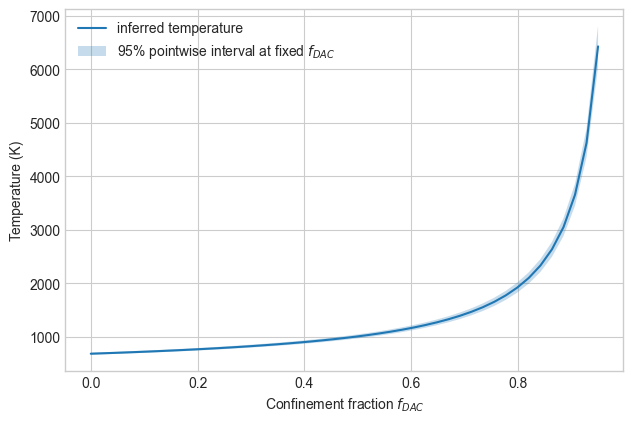

f_DAC=0.000: T=684.8 +/- 9.7 K
f_DAC=0.475: T=978.6 +/- 18.3 K
f_DAC=0.950: T=6429.7 +/- 197.3 K


In [5]:
uncertain_eos = EOSUncertainty(eos, parameter_errors={"gamma0": 0.05})
uncertain_fractions = np.linspace(0.0, 0.95, 45)
predictions = [
    uncertain_eos.evaluate(
        "temperature_from_volumes",
        ambient_volume,
        heated_volume,
        f_dac=fraction,
        argument_sigmas={0: 1e-5, 1: 1e-5},
    )
    for fraction in uncertain_fractions
]

values = np.array([prediction.value for prediction in predictions])
lower = np.array([prediction.lower for prediction in predictions])
upper = np.array([prediction.upper for prediction in predictions])

fig, ax = plt.subplots(figsize=(7.2, 4.7))
ax.plot(uncertain_fractions, values, label="inferred temperature")
ax.fill_between(
    uncertain_fractions,
    lower,
    upper,
    alpha=0.25,
    label="95% pointwise interval at fixed $f_{DAC}$",
)
ax.set(xlabel=r"Confinement fraction $f_{DAC}$", ylabel="Temperature (K)")
ax.legend()
plt.show()

for index in (0, 22, 44):
    prediction = predictions[index]
    print(
        f"f_DAC={uncertain_fractions[index]:.3f}: "
        f"T={prediction.value:.1f} +/- {prediction.standard_error:.1f} K"
    )

## The singular boundary is rejected

`f_dac=1` would divide the reduced cold-pressure difference by zero and has no
finite temperature solution in this model.

In [6]:
try:
    eos.temperature_from_volumes(ambient_volume, heated_volume, f_dac=1.0)
except ValueError as error:
    print(type(error).__name__ + ":", error)

ValueError: f_dac must be greater than or equal to zero and less than one


## Takeaways

1. `f_dac` is a boundary-condition assumption, not a fraction of cold pressure.
2. Verify pressure closure after inferring temperature.
3. Propagate both measured volume errors and available EOS uncertainty.
4. Report a sensitivity sweep because the solution becomes ill-conditioned as
   $f_{DAC}$ approaches one.